## Simple Neural Network in Python using TensorFlow

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf

import warnings
warnings.filterwarnings("ignore")

## Steps before Creating a Neural Network (Preprocess the Data)

In [5]:

# Load the Titanic dataset
titanic = sns.load_dataset('titanic')

# Preprocess the data
# Drop rows with missing values in 'age' and 'embarked'
titanic.dropna(subset=['age', 'embarked'], inplace=True)

# Convert categorical variables to dummy/indicator variables
titanic = pd.get_dummies(titanic, columns=['sex', 'embarked', 'class', 'who', 'deck'], drop_first=True)

# Select features and target variable
X = titanic.drop(['survived', 'alive', 'embark_town', 'adult_male', 'alone'], axis=1)
y = titanic['survived']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Shape of the training and testing sets
print(f"Training set shape: {X_train.shape}, Testing set shape: {X_test.shape}")

Training set shape: (569, 18), Testing set shape: (143, 18)


In [6]:
# Building the Model

# Define the layers of the neural network
input_layer = tf.keras.layers.Dense(10, activation='relu', input_shape=(X_train.shape[1],))

# Output layer with a single neuron for binary classification
output_layer = tf.keras.layers.Dense(1, activation='sigmoid')

# Combine the layers into a model
model = tf.keras.models.Sequential([input_layer, output_layer])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

2026-08-02 18:09:10.205495: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-08-02 18:09:10.205882: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-08-02 18:09:10.208581: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
I0000 00:00:1785676150.208924   71805 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1785676150.210175   71805 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [7]:
%%time
# Training the Model
# Train the model on the training data
model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=1)

Epoch 1/50


2026-08-02 18:10:08.328674: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.6274 - loss: 0.6788
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7469 - loss: 0.5969
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7715 - loss: 0.5443
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7750 - loss: 0.5116 
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7856 - loss: 0.4923
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7979 - loss: 0.4770
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8102 - loss: 0.4668
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8120 - loss: 0.4581
Epoch 9/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8120 - loss: 0.4512
Epoch 10/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8137 - loss: 0.4460
Epoch 11/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8137 - loss: 0.4408
Epoch 12/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8137 - loss: 0.4

In [9]:
# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Test Loss: {loss},\nTest Accuracy: {accuracy}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7692 - loss: 0.4955 
Test Loss: 0.49552443623542786,
Test Accuracy: 0.7692307829856873


## Let's see all the steps in action within one snippet of code

In [14]:
%%time

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import seaborn as sns

# remove warnings
import warnings
warnings.filterwarnings("ignore")

# Load the Titanic dataset
titanic = sns.load_dataset('titanic')

# Preprocess the data
titanic.dropna(subset=['age', 'embarked'], inplace=True)

# Convert categorical variables to dummy/indicator variables
titanic = pd.get_dummies(titanic, columns=['sex', 'embarked', 'class', 'who', 'deck'], drop_first=True)

# Select features and target variable
X = titanic.drop(['survived', 'alive', 'embark_town', 'adult_male', 'alone'], axis=1)
y = titanic['survived']

# Cast to float32 -- pd.get_dummies produces bool columns in recent pandas,
# and TensorFlow prefers a clean numeric dtype
X = X.astype('float32')

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Building the Model
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Test Loss: {loss},\nTest Accuracy: {accuracy}")

Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.6681 - loss: 0.7863 - val_accuracy: 0.7368 - val_loss: 0.6113
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7099 - loss: 0.6926 - val_accuracy: 0.7982 - val_loss: 0.5665
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7363 - loss: 0.6353 - val_accuracy: 0.8070 - val_loss: 0.5434
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7516 - loss: 0.5939 - val_accuracy: 0.8070 - val_loss: 0.5290
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7538 - loss: 0.5642 - val_accuracy: 0.8070 - val_loss: 0.5194
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7582 - loss: 0.5402 - val_accuracy: 0.8070 - val_loss: 0.5155
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7670 - loss: 0.5225 - val_accuracy: 0.8246 - val_loss: 0.5130
Epoch 8/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7780 - loss: 0.5080 - val_accuracy: 0.8158 - val_loss

## **Assignment:** Plot the Training and Validation Accuracy and Loss for each epoch

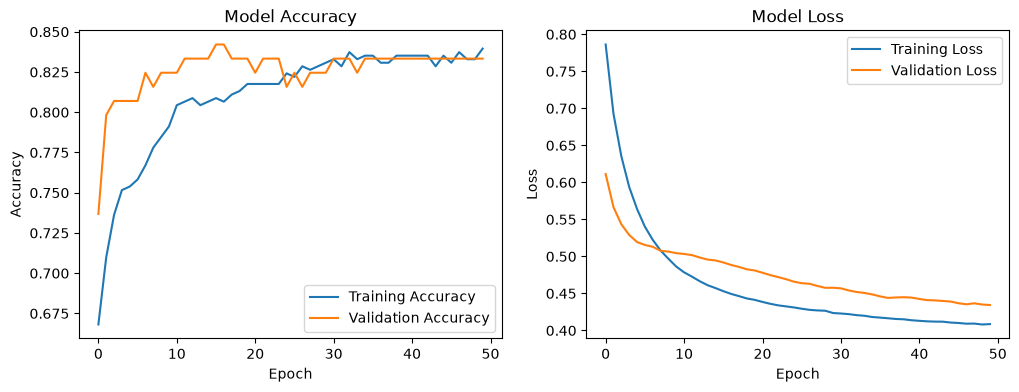

In [15]:
# Plot the Training and Validation Accuracy and Loss for each epoch
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

## Check if GPU is available

In [16]:
import sys

import tensorflow as tf
import pandas as pd
import sklearn as sk
import scipy as sp
import tensorflow as tf
import platform

print(f"Python Platform: {platform.platform()}")
print(f"Python version: {sys.version}")
print(f"TensorFlow version: {tf.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Scikit-learn version: {sk.__version__}")
print(f"SciPy version: {sp.__version__}")
gpu = len(tf.config.list_physical_devices('GPU')) > 0
print(f"GPU is", "available" if gpu else "not available")

Python Platform: macOS-26.2-arm64-arm-64bit
Python version: 3.12.13 (main, May 10 2026, 19:20:41) [Clang 22.1.3 ]
TensorFlow version: 2.18.1
Pandas version: 3.0.5
Scikit-learn version: 1.9.0
SciPy version: 1.17.1
GPU is available
